In [36]:
import numpy as np
import matplotlib.pyplot as plt
from lsst.daf.butler import Butler
import polars
from tqdm import tqdm
import lsst.geom as geom
import pandas as pd
import matplotlib.colors as colors

In [25]:
repo = "dp2_prep"
collection = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"

PARQUET_COLUMNS = [
    'slot_Centroid_x', 'slot_Centroid_y', 'detector', 'psf_max_value',
]

butler = Butler(repo, collections=collection)

In [106]:
def getStarImage(visit, detector, stampSize = 41):

#stampSize = 41
#visit = 2025050400608
#detector = 42
    
    dataID = {
        "instrument": "LSSTCam", 
        "visit": visit,
        "detector": detector,
    }
    uri = butler.getURI("refit_psf_star", **dataID)
    parquet_path = uri.geturl()
    psfTable = polars.scan_parquet(parquet_path).select(PARQUET_COLUMNS).collect()
    psfTable = psfTable.filter(polars.col("detector") == detector)
    
    calexp = butler.get("preliminary_visit_image", **dataID)
    VMIN = 1e-5
    VMAX = 1e-1
    try: 
        plt.figure(figsize=(8,8))
        plt.subplots_adjust(wspace=0.)
        stars = []
        weights = [] 
        for i in range(9):
            positionStar = geom.Point2D(psfTable['slot_Centroid_x'][i], psfTable['slot_Centroid_y'][i])
            srcImg = calexp.getCutout(positionStar, geom.Extent2I(stampSize, stampSize))
            im = srcImg.getMaskedImage()
            star = im.image.array / np.sum(im.image.array)
            plt.subplot(3,3,i+1)
            plt.imshow(star, cmap=plt.cm.Greys_r, vmin=0, vmax=np.max(star))
            plt.gca().invert_yaxis()
            plt.xticks([],[])
            plt.yticks([],[])
            if i == 1:
                plt.title(f"{visit} | {detector}")
    except:
        print('failed')

In [112]:
badVisitDic = pd.read_pickle('data/badDetectorList.pkl')
zernike_table =  pd.read_pickle("data/visit_to_band_mapv2.pkl")

visits = np.array([visit for visit in badVisitDic if visit in zernike_table])
z4 = np.array([np.nanmedian(zernike_table[visit]['z4']) for visit in visits])
FiltreBad = abs(z4+0.25)>1.8
print(np.sum(FiltreBad))

93


failed
failed
failed
failed
failed


/tmp/ipykernel_1922/809586224.py:21: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,8))


failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed
failed


<Figure size 800x800 with 0 Axes>

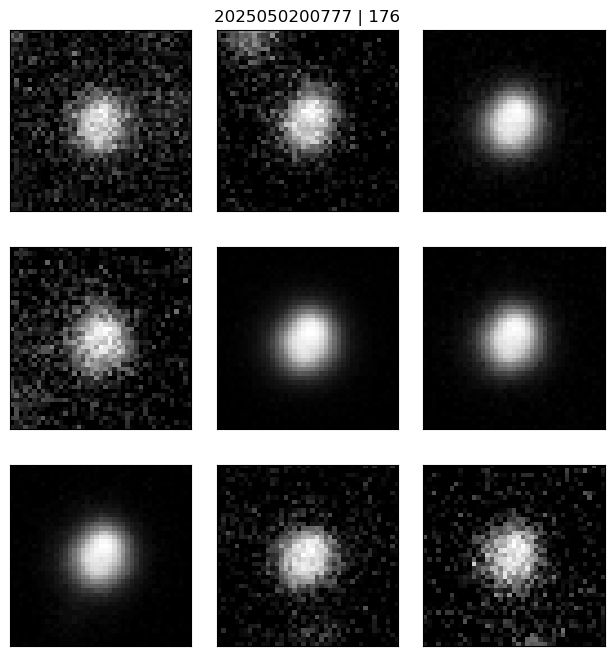

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

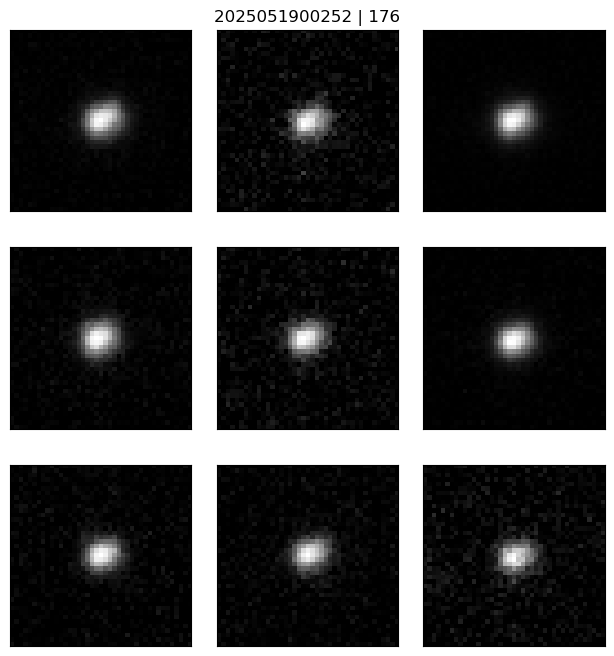

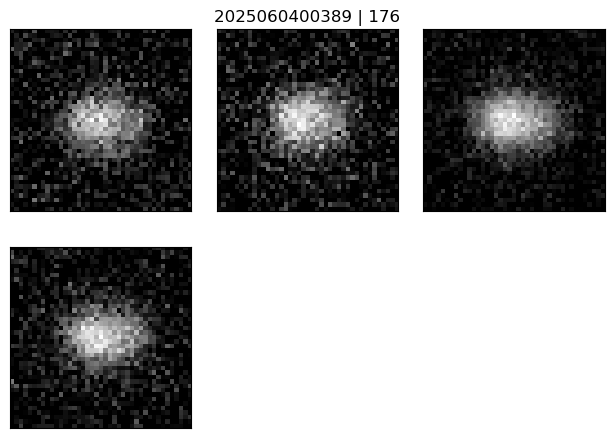

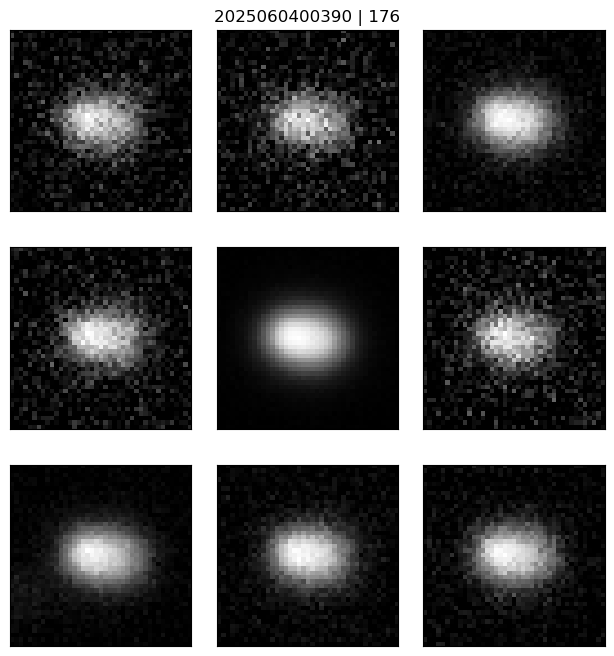

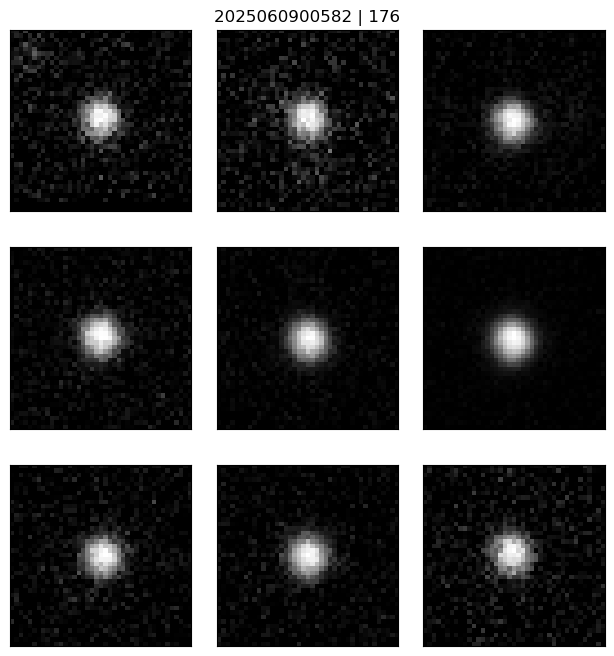

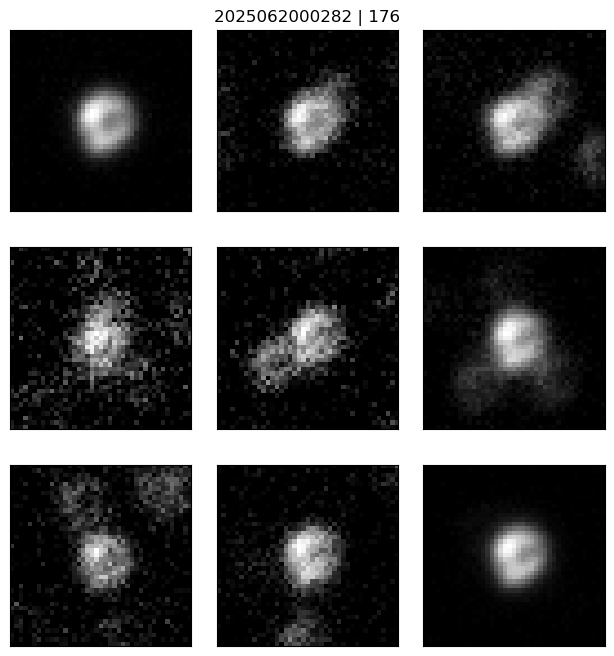

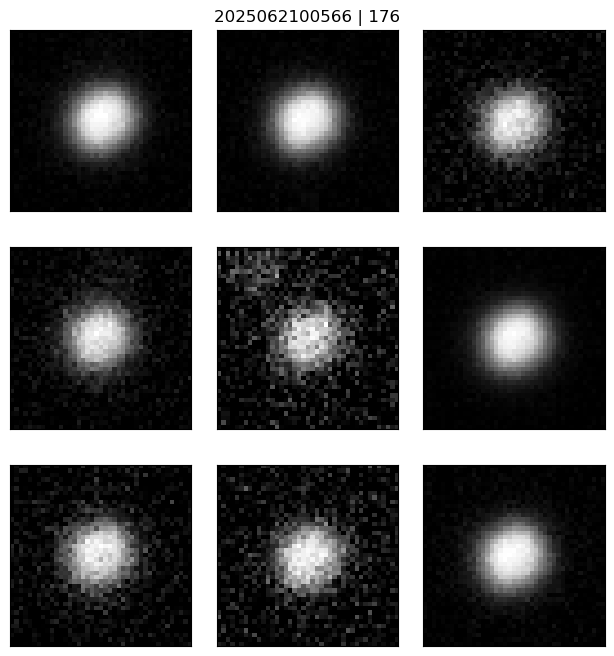

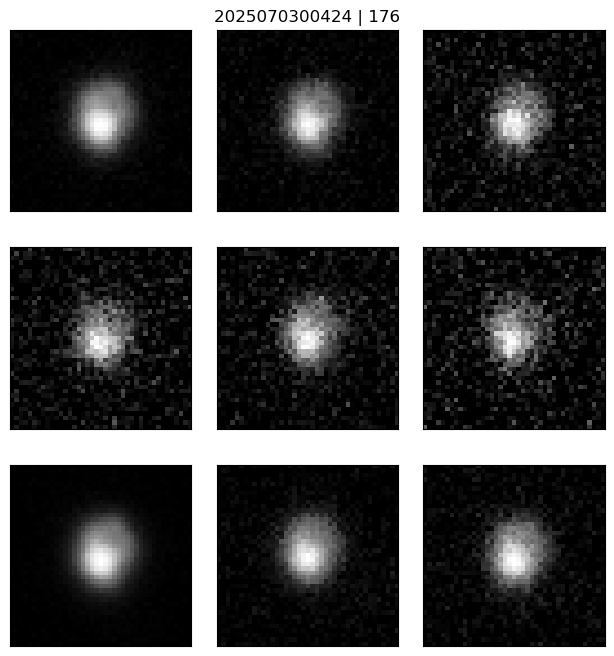

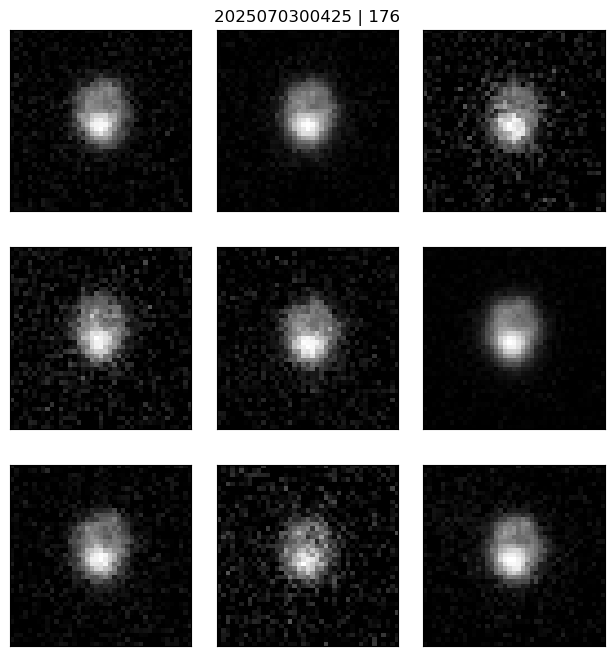

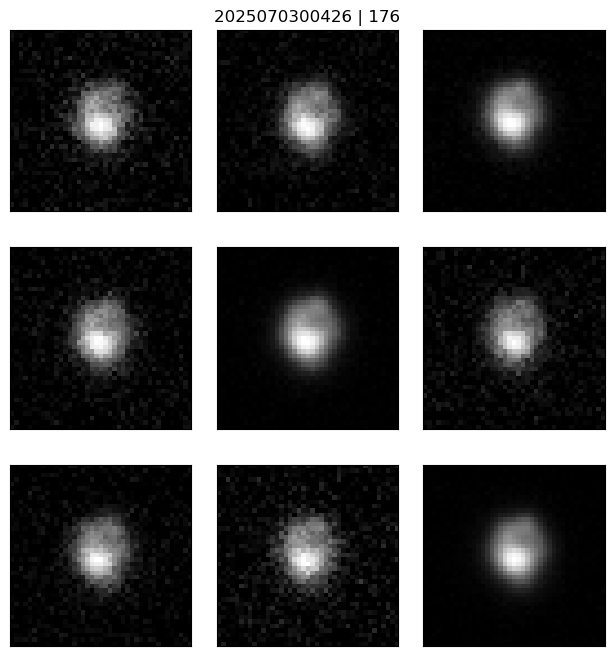

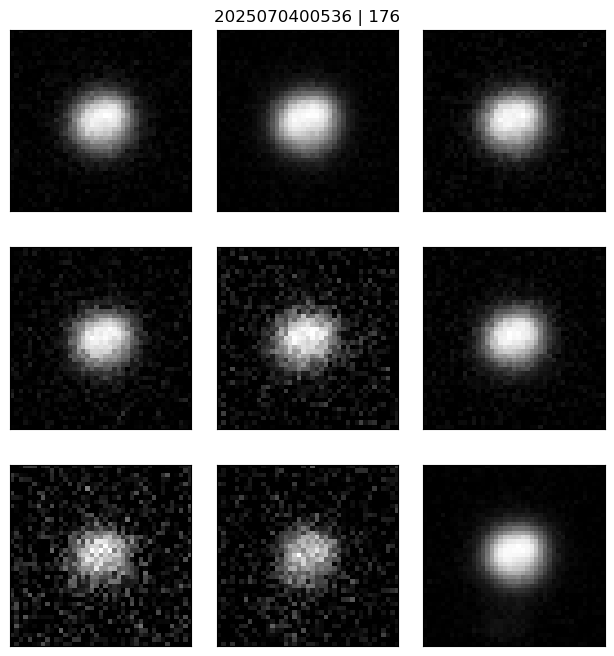

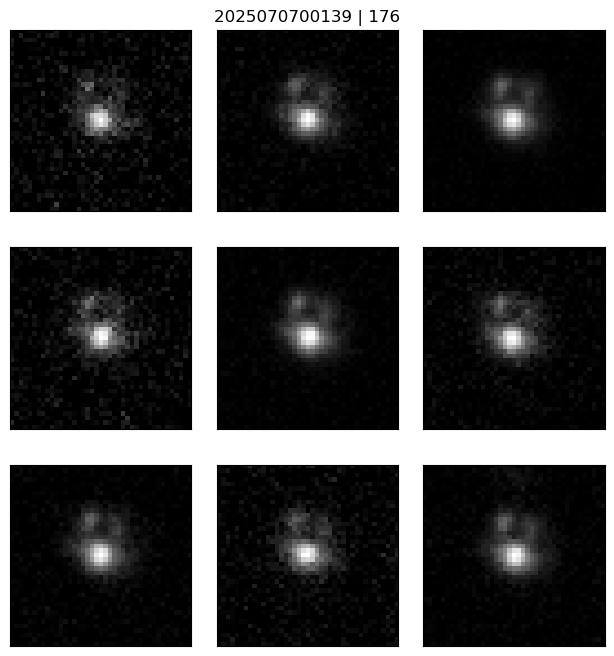

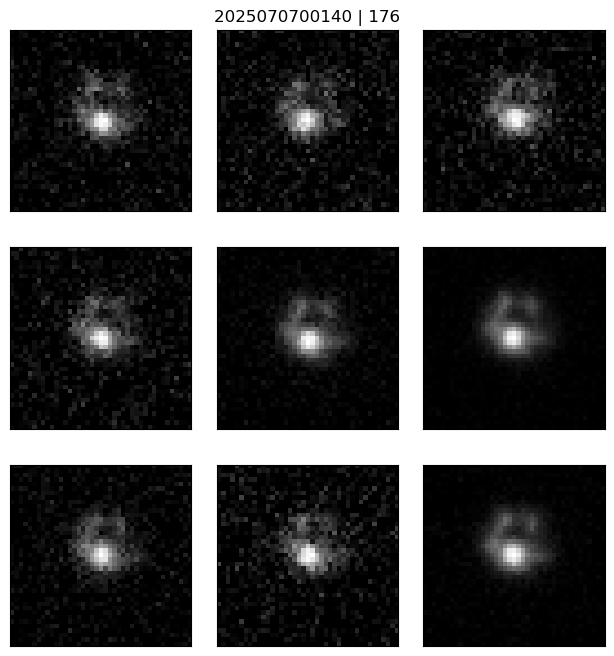

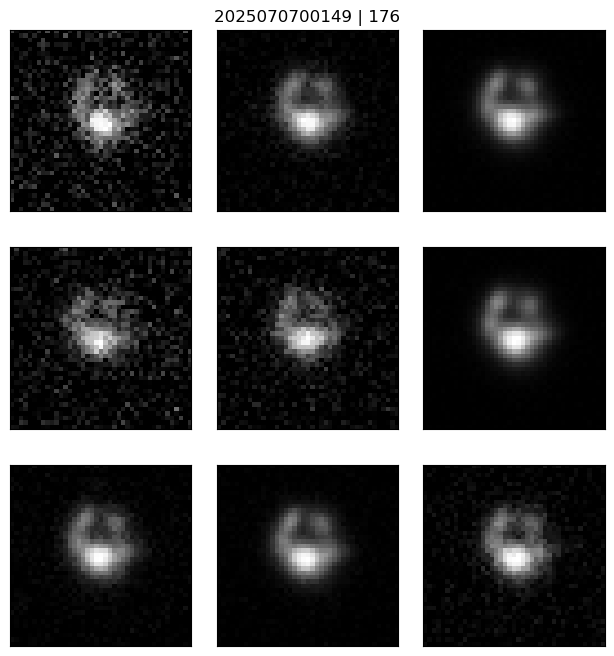

<Figure size 800x800 with 0 Axes>

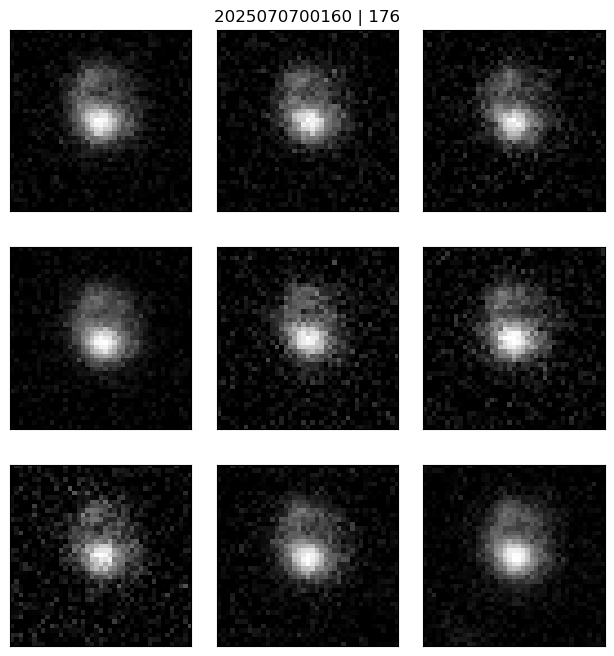

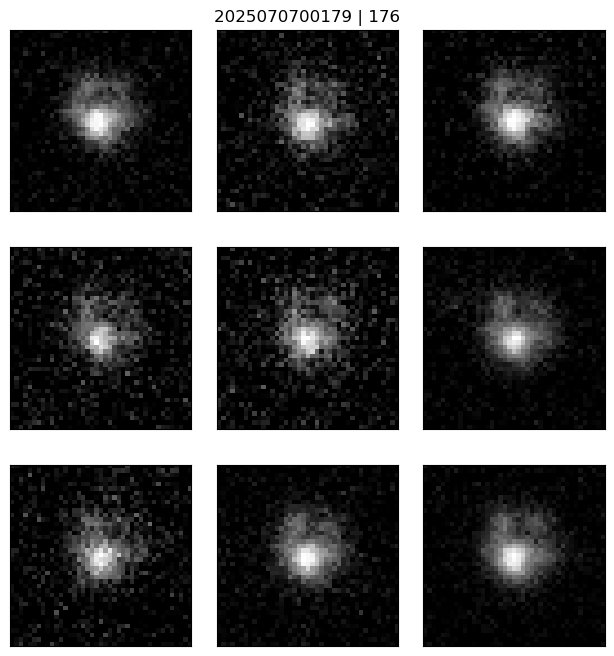

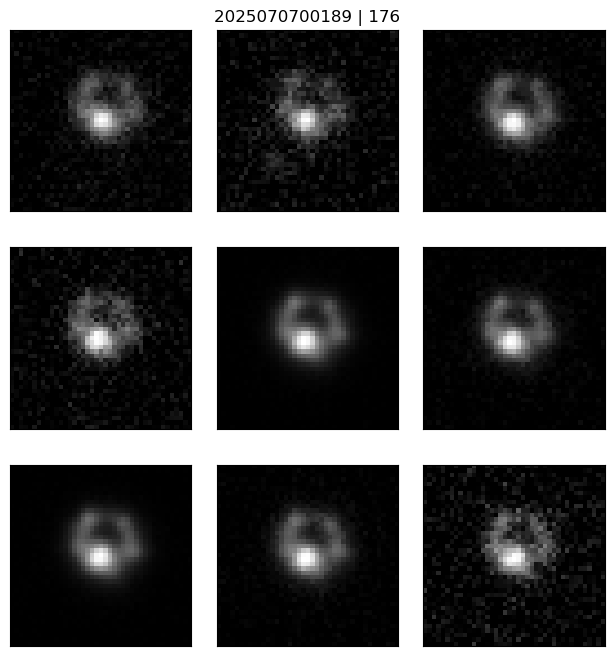

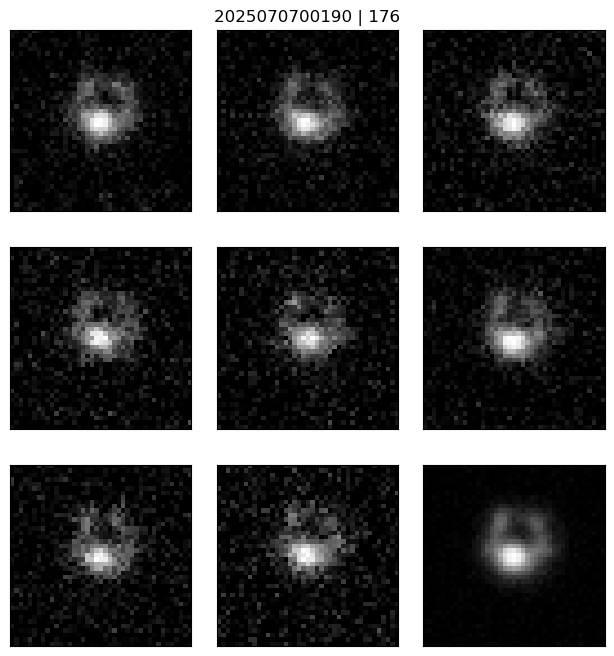

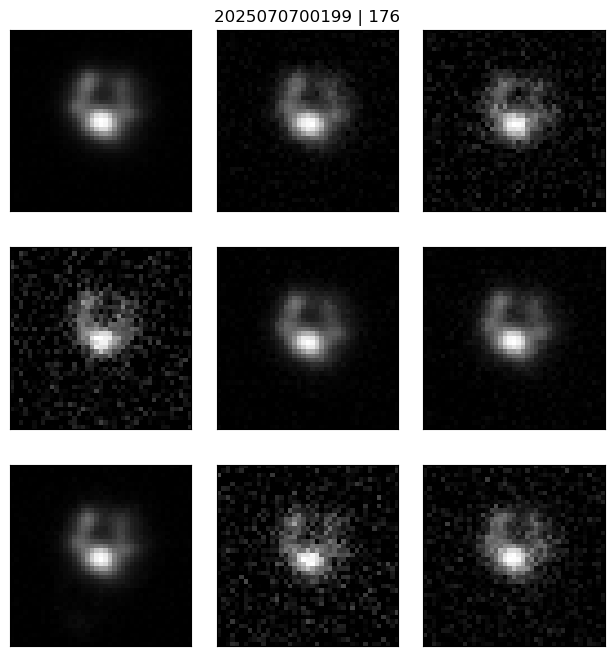

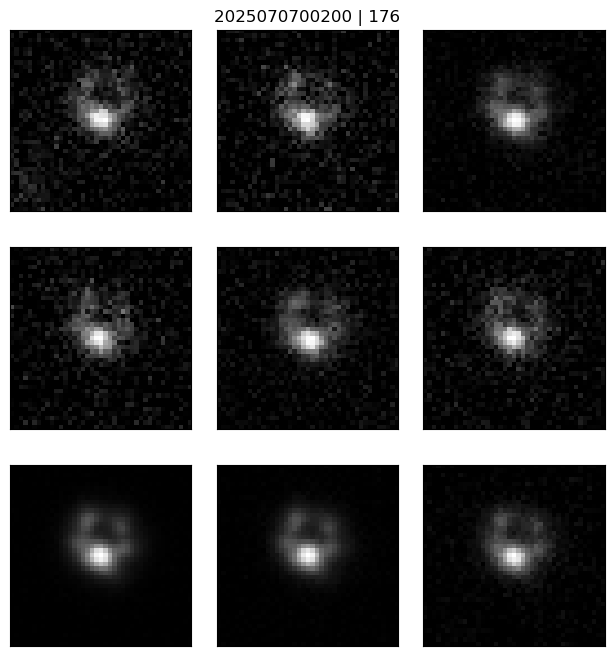

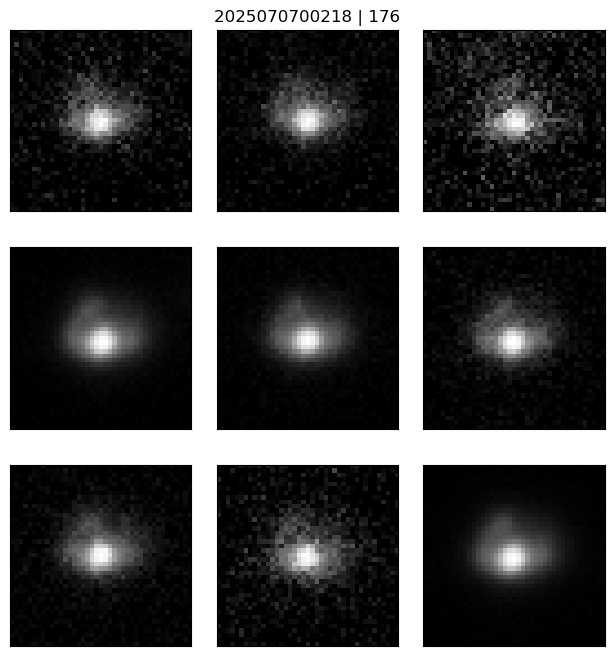

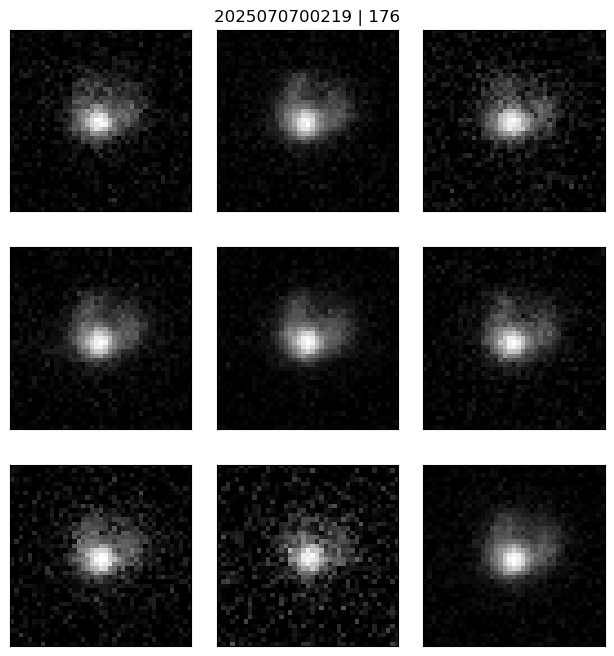

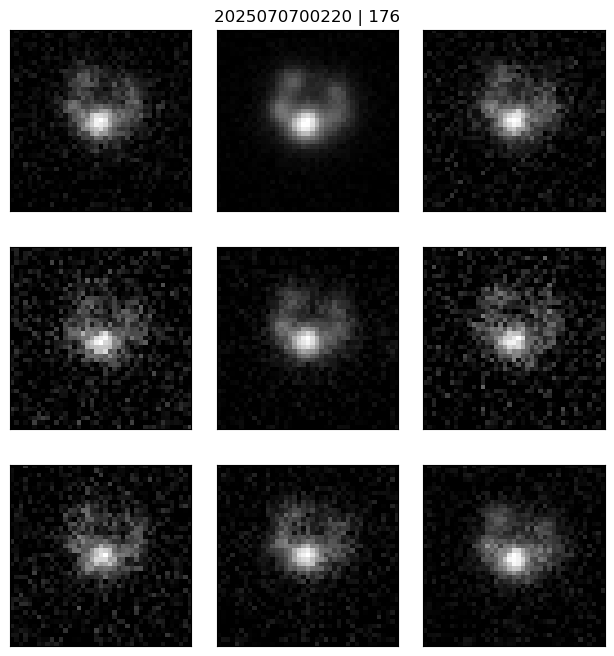

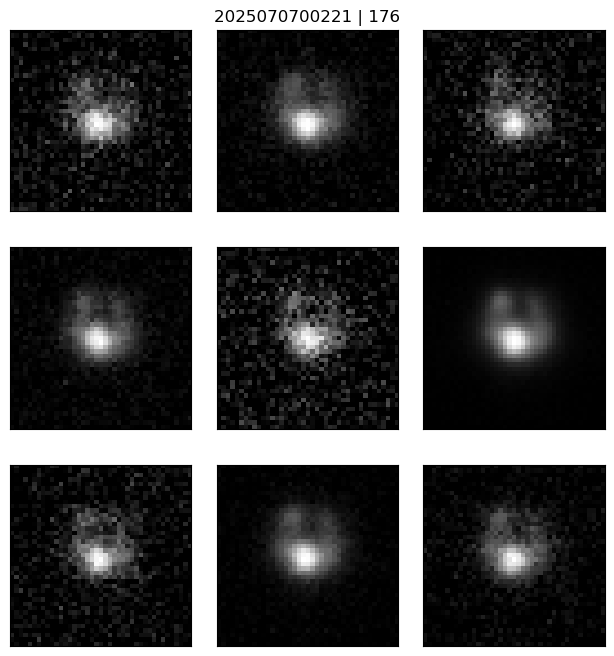

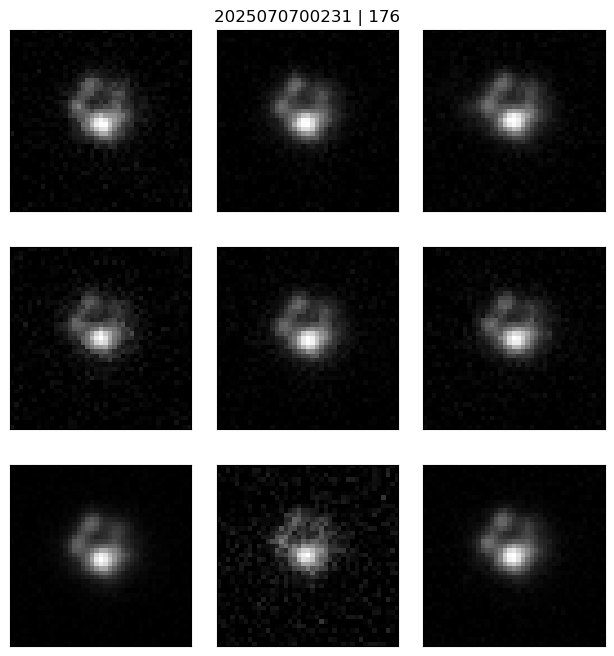

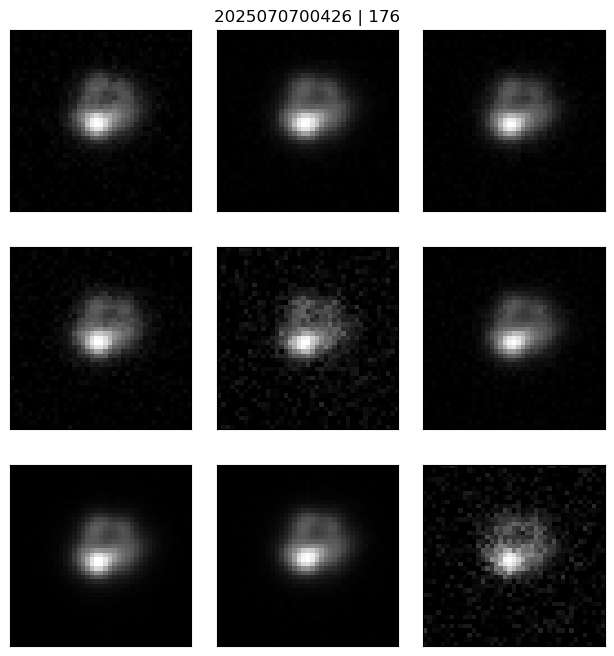

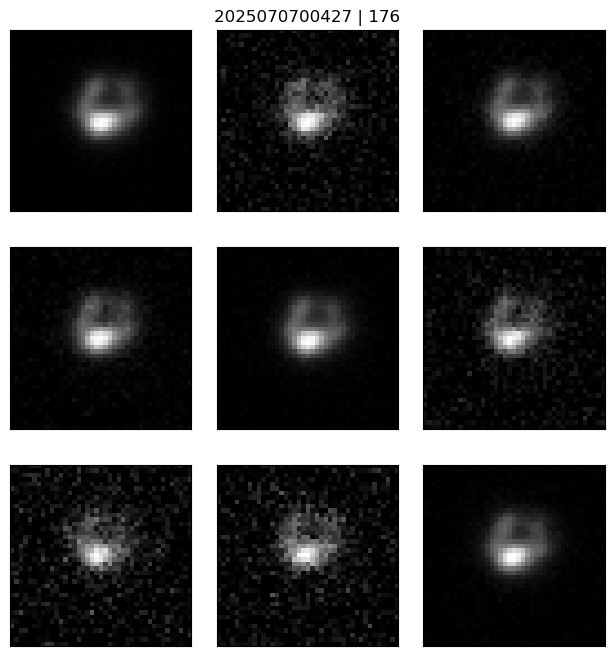

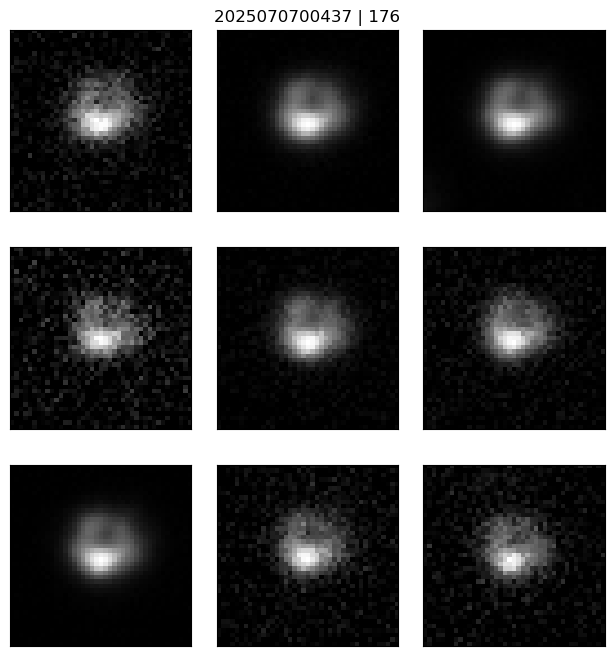

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

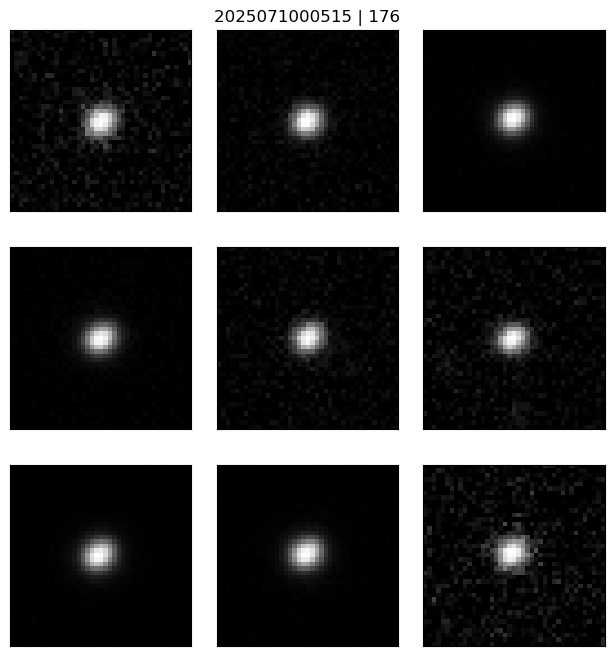

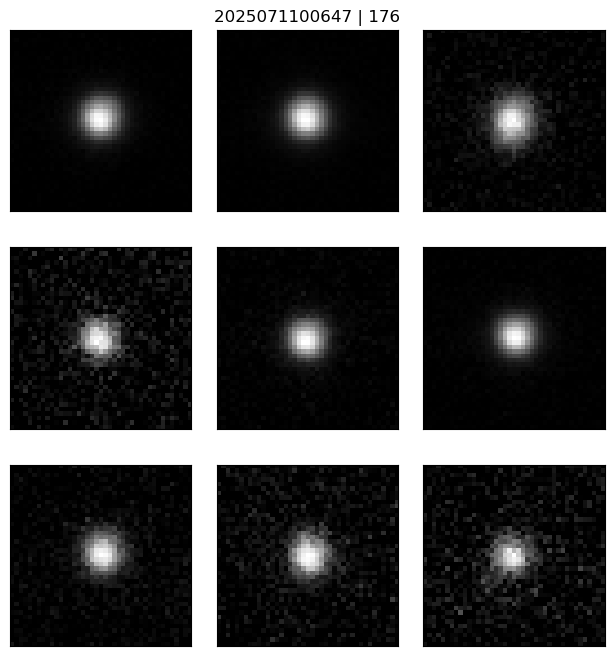

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

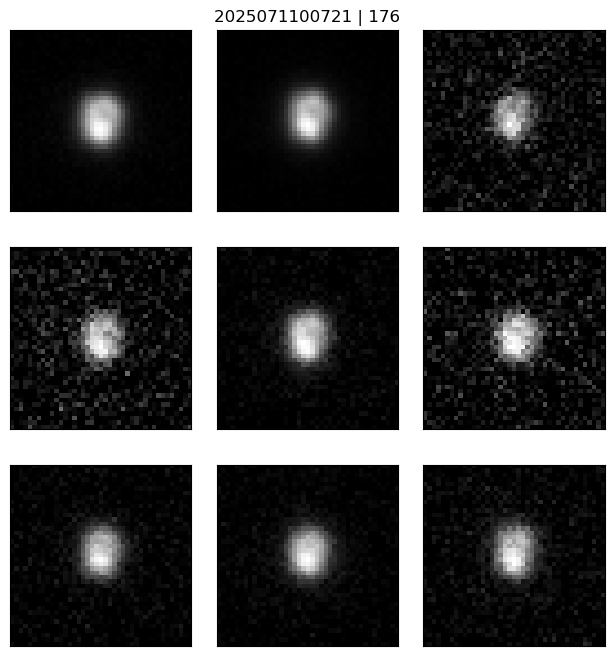

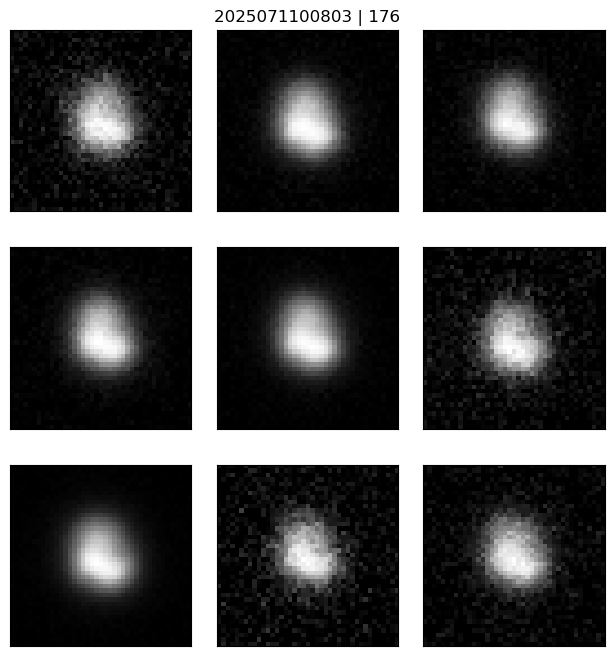

<Figure size 800x800 with 0 Axes>

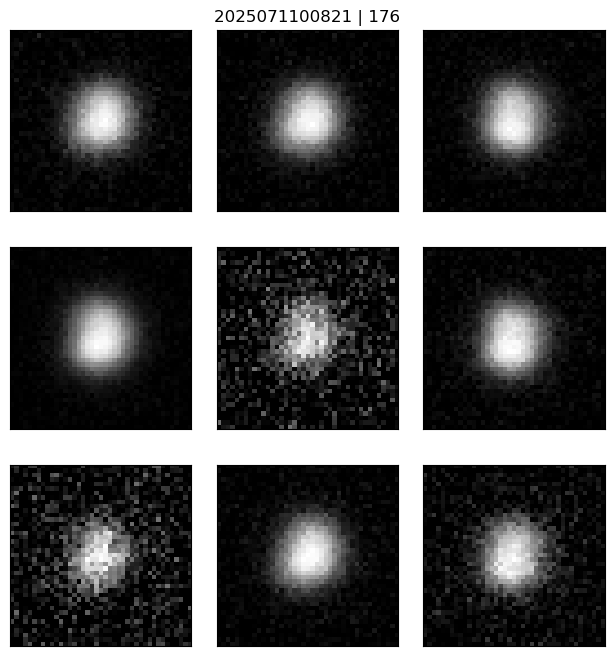

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

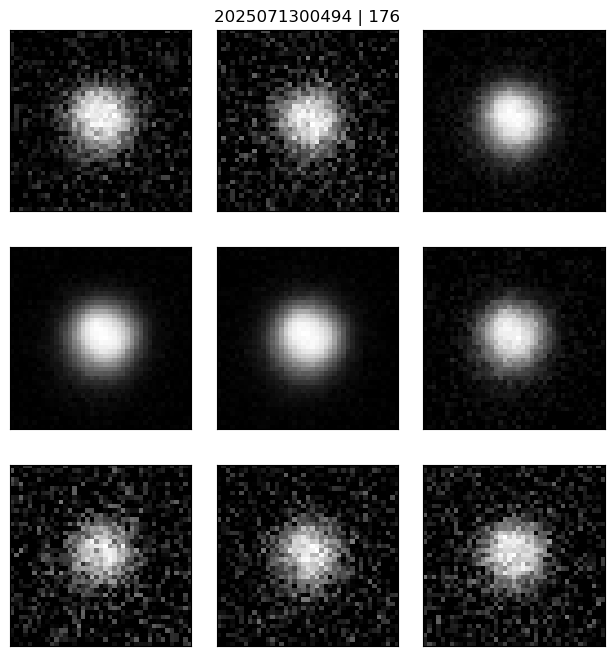

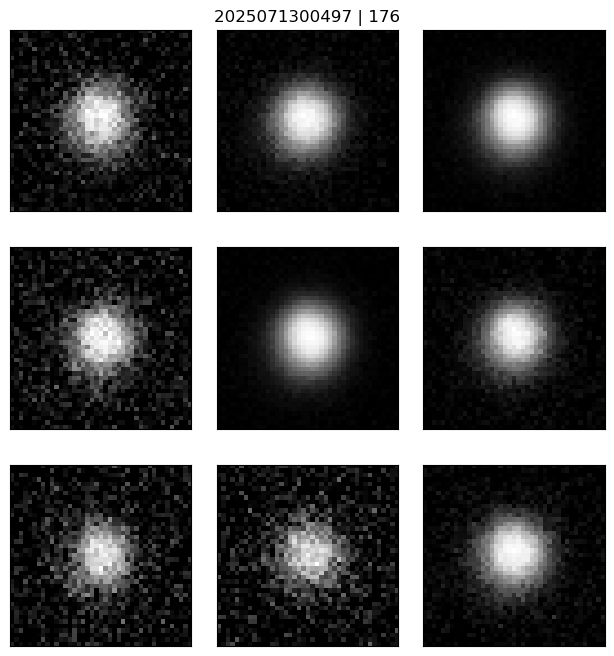

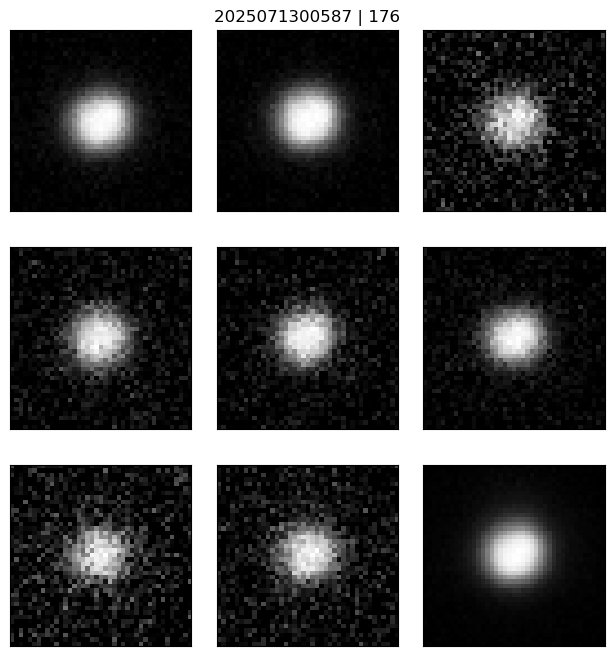

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

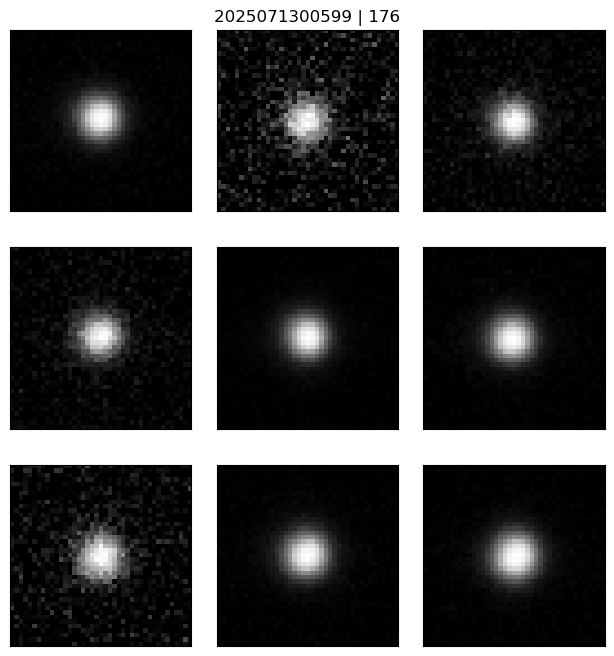

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

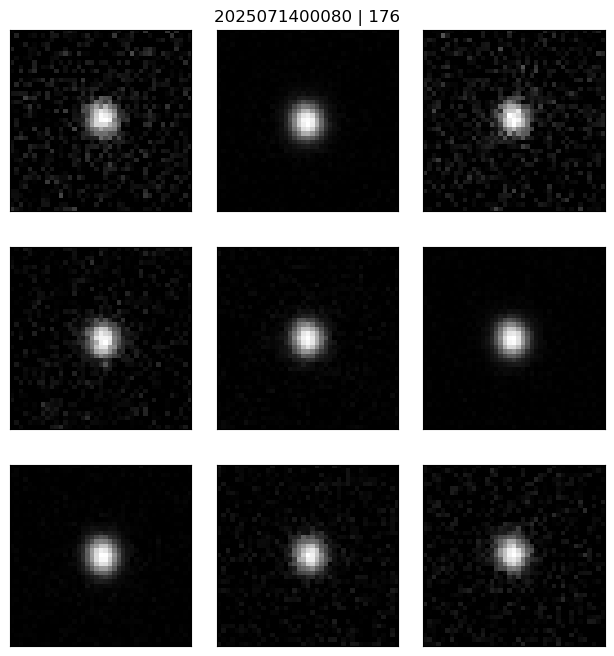

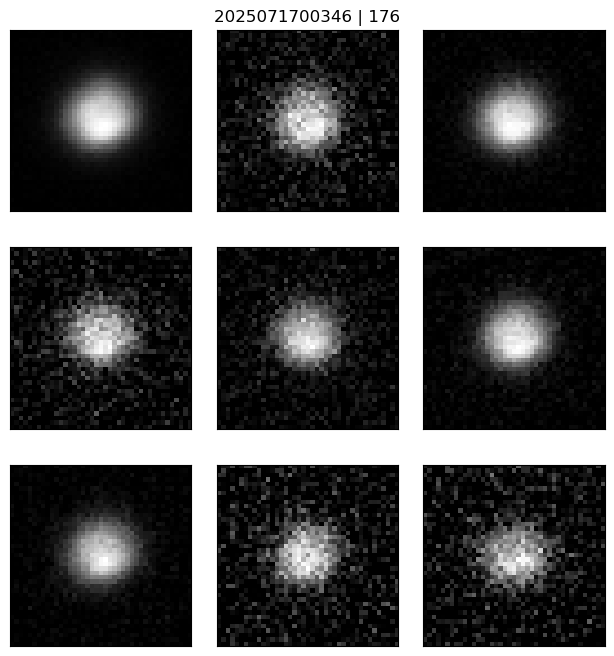

<Figure size 800x800 with 0 Axes>

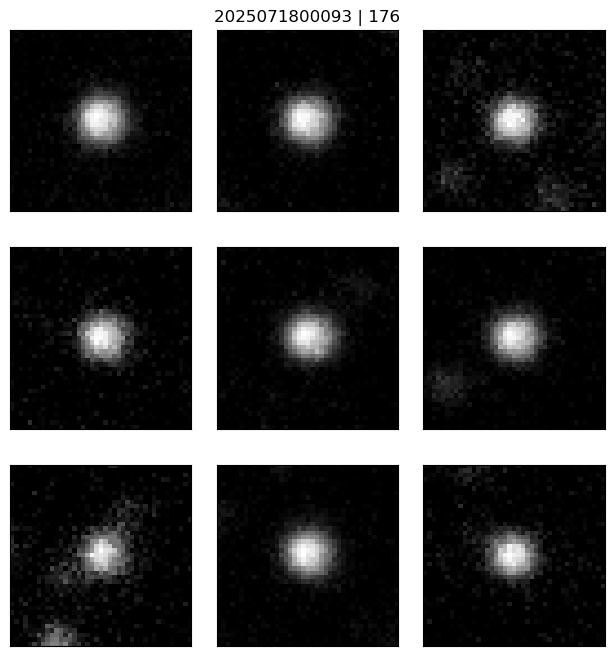

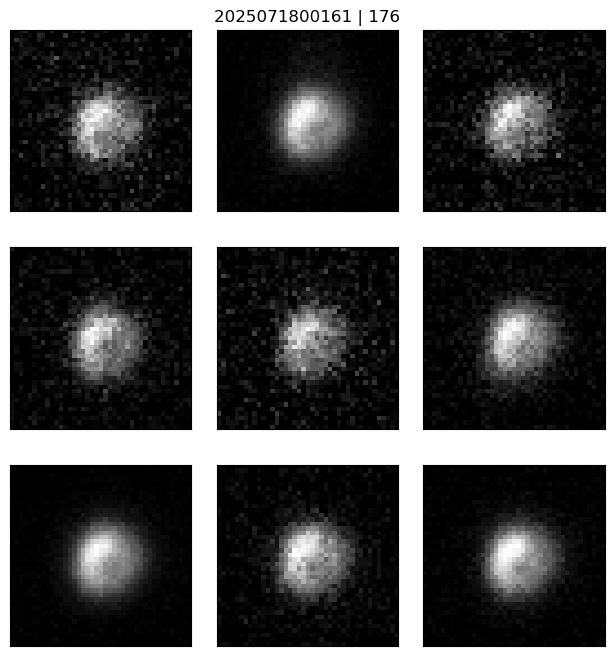

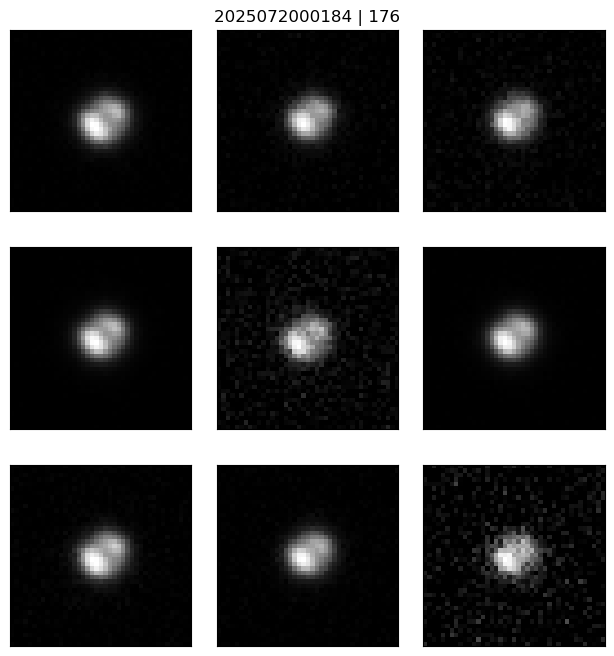

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

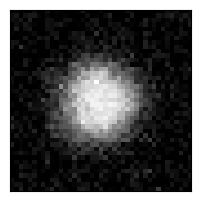

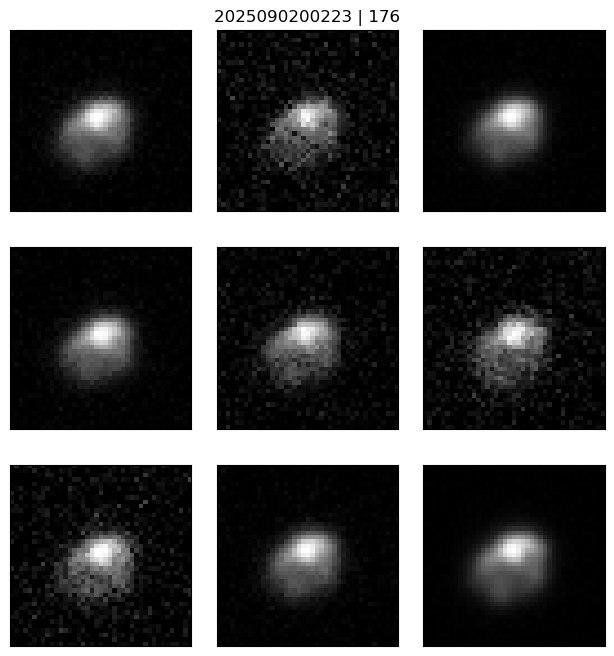

<Figure size 800x800 with 0 Axes>

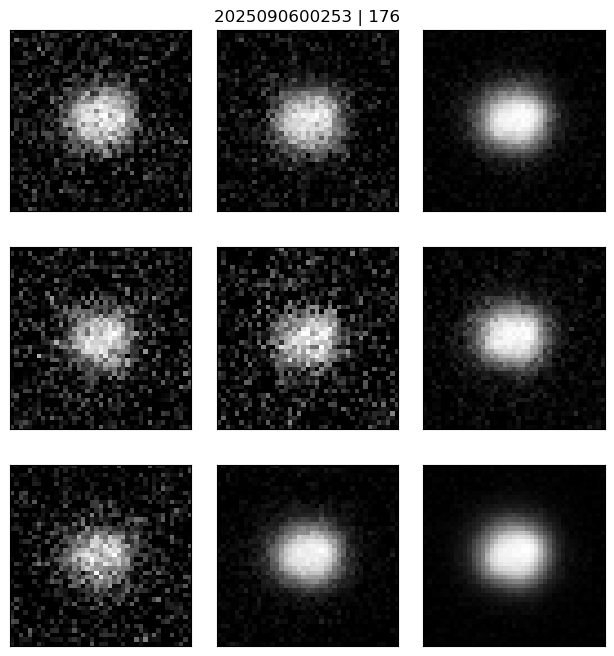

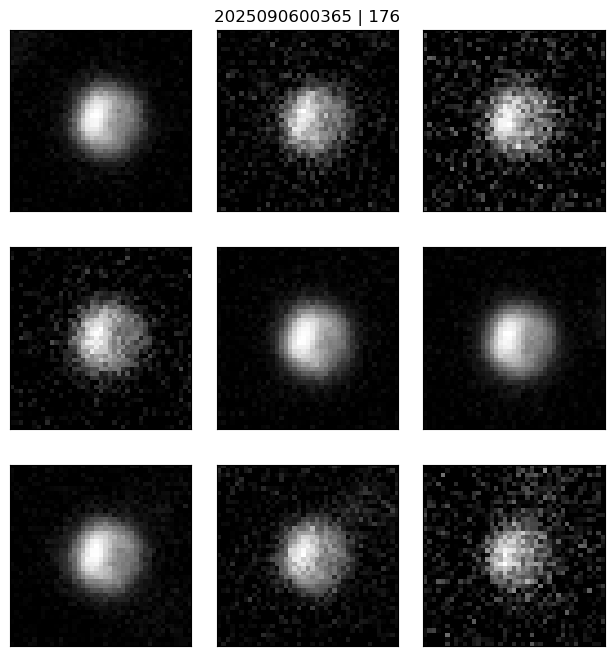

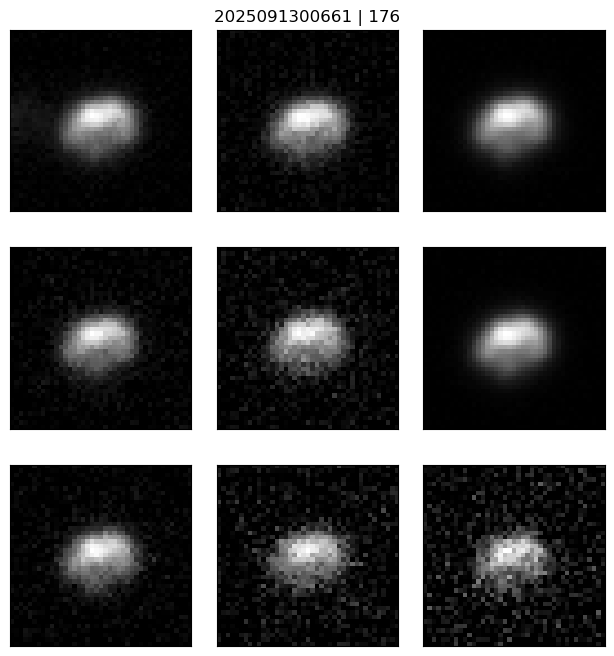

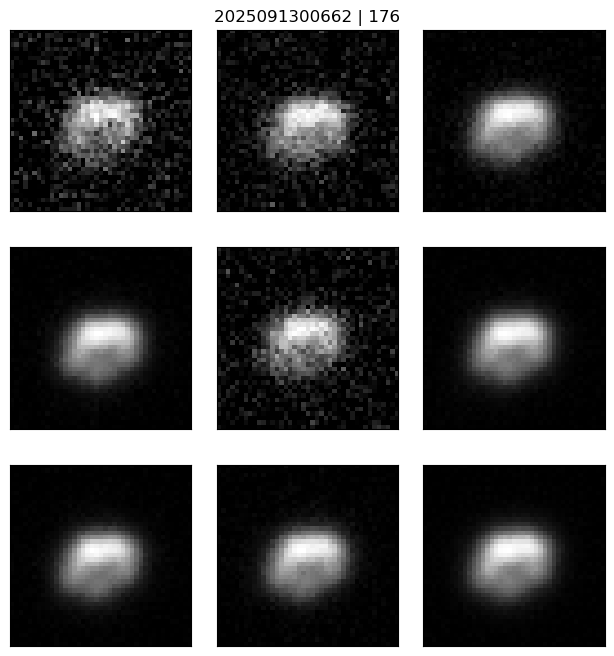

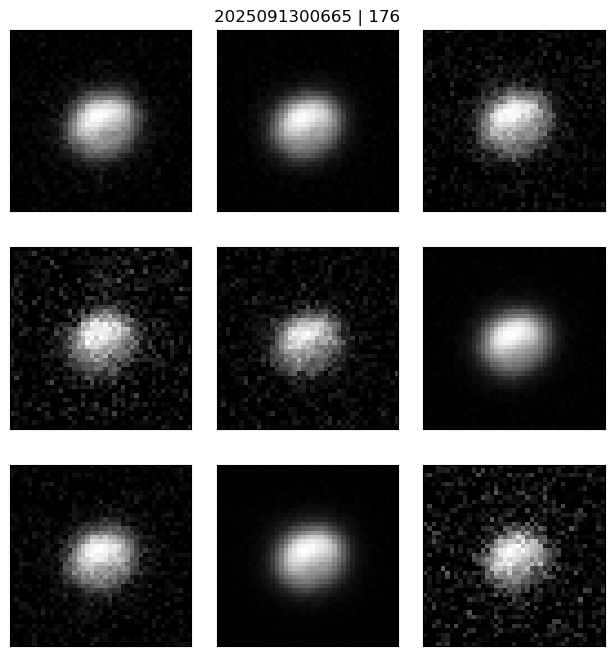

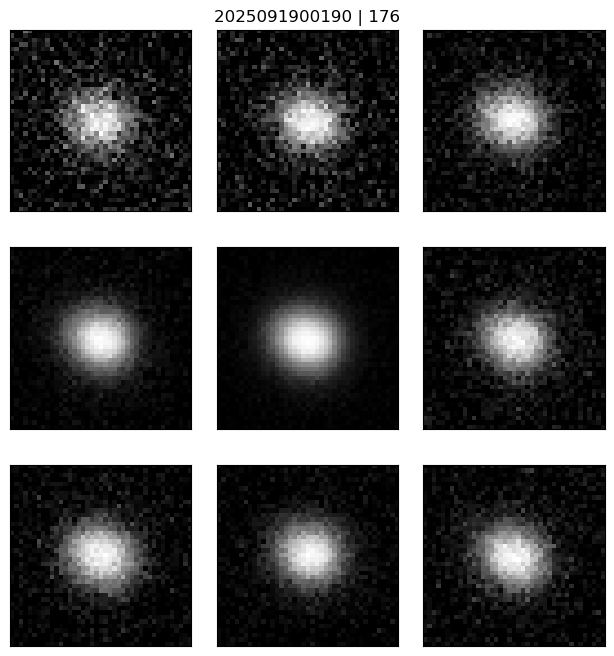

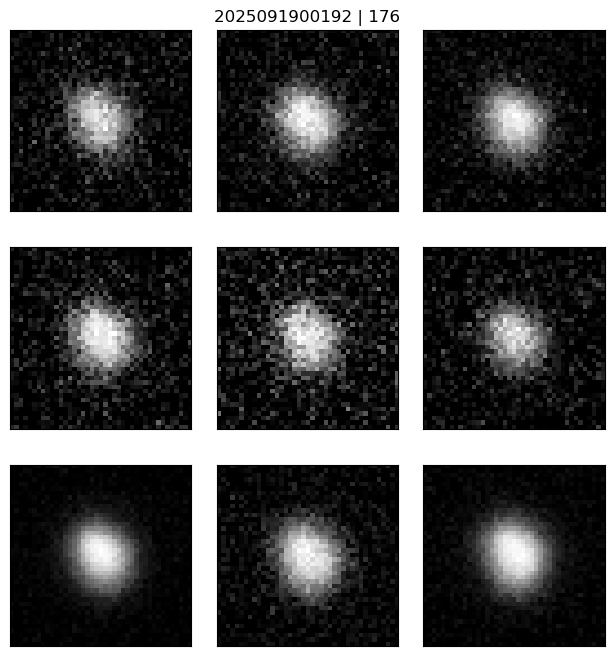

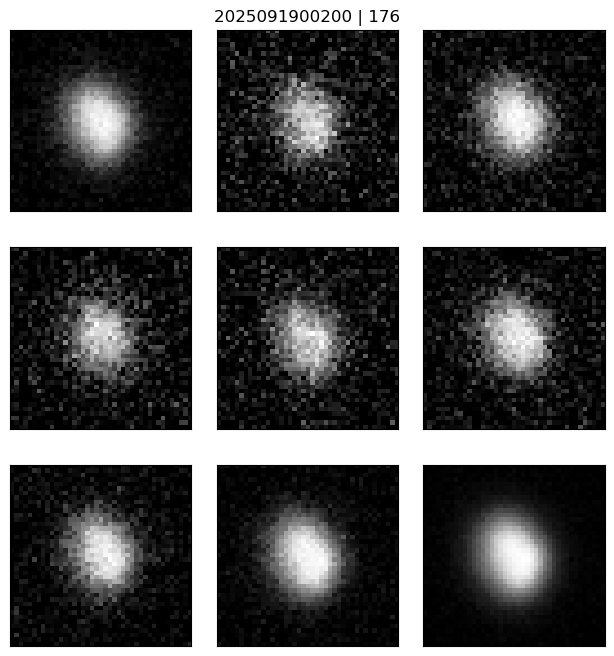

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

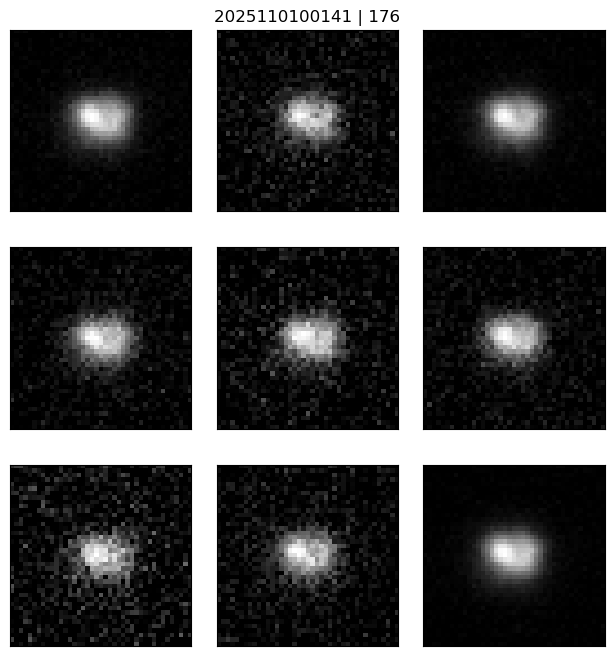

<Figure size 800x800 with 0 Axes>

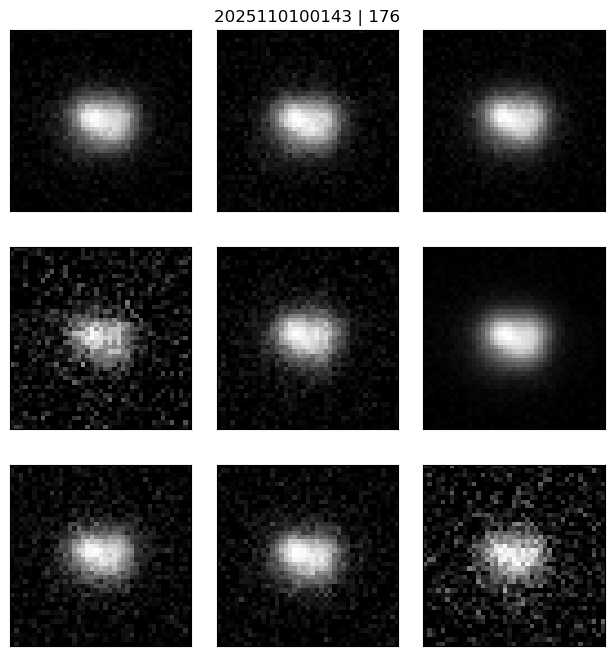

<Figure size 800x800 with 0 Axes>

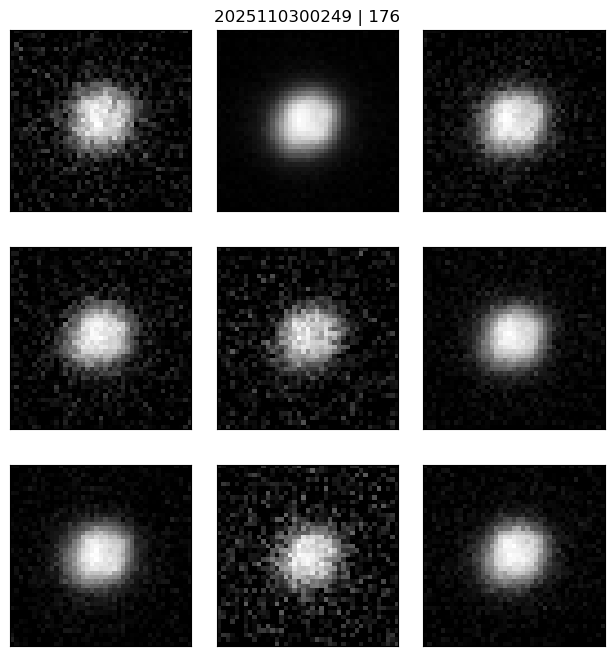

In [115]:
N_bad = 0 

for visit in visits[FiltreBad]:
    getStarImage(visit, 176, stampSize = 41)
    N_bad += 1
    if N_bad > 100:
        break

In [81]:
#zernikeDic = {}
#for visit in zernike_table:
#        if visit in visitsDP2 and zernike_table[visit]['band'] in bands:
#            if visit not in zernikeDic:
#                zernikeDic[visit] = {
#                    'zernike': zernike_table[visit][zernikeKey],
#                    'band': zernike_table[visit]['band'],
#                }

    # Get all Zernike values for histogram
#    z_all = [np.median(zernikeDic[visit]['zernike']) for visit in zernikeDic]

In [89]:
np.nanmedian(zernike_table[2025050400608]['z4'])

np.float64(0.1253430787473917)

In [93]:
visits = np.array([visit for visit in badVisitDic if visit in zernike_table])
z4 = np.array([np.nanmedian(zernike_table[visit]['z4']) for visit in visits])

In [95]:
FiltreBad

np.int64(50)